# 🧠 Beyin MR Görüntülerinden Tümör Sınıflandırması
## Derin Öğrenme ve Grad-CAM ile Açıklanabilirlik Analizi

Bu notebook, beyin MR görüntülerini 4 sınıfa ayıran iki farklı modeli (Custom CNN ve EfficientNetB0) eğitir, karşılaştırır ve Grad-CAM ile en başarılı modelin kararlarını görselleştirir.

**Sınıflar:** glioma, meningioma, notumor, pituitary
**Veri seti:** Brain Tumor MRI Dataset (Kaggle - Masoud Nickparvar)
**Giriş boyutu:** 224×224×3

---


## 1. Kurulum ve Kütüphaneler

In [ ]:
# Google Colab GPU kontrolü
import tensorflow as tf
print("TensorFlow versiyonu:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✓ GPU hazır")
else:
    print("⚠ UYARI: GPU bulunamadı! Runtime > Change runtime type > GPU seçin.")

TensorFlow versiyonu: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ GPU hazır


In [ ]:
# Reproducibility için sabit seed
import numpy as np
import random
import os
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f"✓ Random seed sabitlendi: {SEED}")

✓ Random seed sabitlendi: 42


In [ ]:
# Gerekli kütüphaneler
import os
import shutil
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Görselleştirme ayarları
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print("✓ Tüm kütüphaneler yüklendi")

✓ Tüm kütüphaneler yüklendi


## 2. Veri Seti İndirme

İki yöntem var:

**A) Kaggle API ile (önerilen):** Kaggle hesabınızdan `kaggle.json` API anahtarınızı indirip Colab'a yükleyin.

**B) Manuel:** [Bu linkten](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) zip olarak indirip Colab'a yükleyin.


In [ ]:
# === Veri seti indirme (yeni Kaggle API token ile) ===
import os
import shutil
import zipfile

# 🔑 Kaggle token'ınızı tırnak içine yapıştırın:
KAGGLE_TOKEN = "KGAT_84d47cbe37e700414051a9497254f7e5"
# Kaggle CLI'yi kur (en güncel versiyon)
!pip install -q --upgrade kaggle

# Token'ı kaydet (yeni sistem)
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN.strip())
os.chmod('/root/.kaggle/access_token', 0o600)
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN.strip()

# Veri setini indir
print("📥 Veri seti indiriliyor (yaklaşık 158 MB, 1-2 dakika)...")
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --force

# Zip dosyasını çıkar
zip_file = 'brain-tumor-mri-dataset.zip'
if os.path.exists(zip_file):
    print("📦 Zip dosyası çıkarılıyor...")
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall('data')
    print("✅ Veri seti hazır: data/ klasöründe")
else:
    print("❌ HATA: Zip dosyası bulunamadı. Token'ı kontrol et.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 15.2 MB/s eta 0:00:00
📥 Veri seti indiriliyor (yaklaşık 158 MB, 1-2 dakika)...
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 249MB/s]

📦 Zip dosyası çıkarılıyor...
✅ Veri seti hazır: data/ klasöründe


In [ ]:
# Veri seti yapısını kontrol et
TRAIN_DIR = 'data/Training'
TEST_DIR = 'data/Testing'

if os.path.exists(TRAIN_DIR):
    print("Eğitim klasörü içeriği:")
    for cls in sorted(os.listdir(TRAIN_DIR)):
        n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
        print(f"  {cls}: {n} görüntü")
    print("\nTest klasörü içeriği:")
    for cls in sorted(os.listdir(TEST_DIR)):
        n = len(os.listdir(os.path.join(TEST_DIR, cls)))
        print(f"  {cls}: {n} görüntü")
else:
    print("⚠ data/Training klasörü bulunamadı. Veri setini yükleyin.")

Eğitim klasörü içeriği:
  glioma: 1400 görüntü
  meningioma: 1400 görüntü
  notumor: 1400 görüntü
  pituitary: 1400 görüntü

Test klasörü içeriği:
  glioma: 400 görüntü
  meningioma: 400 görüntü
  notumor: 400 görüntü
  pituitary: 400 görüntü


## 3. Veri Keşfi ve Görselleştirme

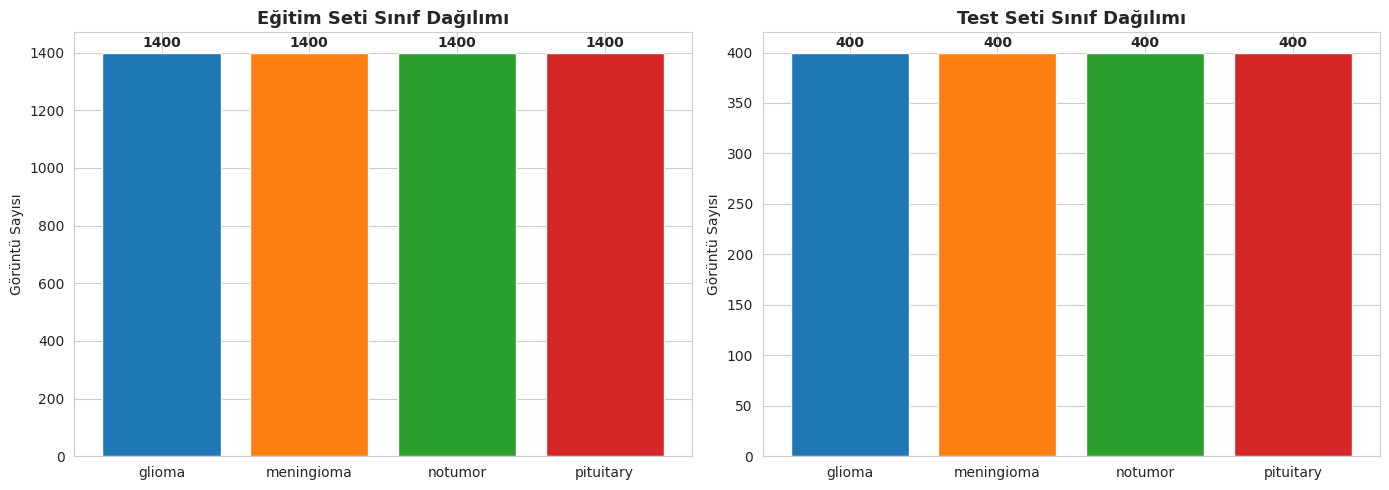

Toplam eğitim: 5600
Toplam test: 1600


In [ ]:
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

# Sınıf dağılımı görselleştirmesi
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in CLASS_NAMES}
test_counts = {cls: len(os.listdir(os.path.join(TEST_DIR, cls))) for cls in CLASS_NAMES}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(train_counts.keys(), train_counts.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Eğitim Seti Sınıf Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Görüntü Sayısı')
for i, (k, v) in enumerate(train_counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].bar(test_counts.keys(), test_counts.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('Test Seti Sınıf Dağılımı', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Görüntü Sayısı')
for i, (k, v) in enumerate(test_counts.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Toplam eğitim: {sum(train_counts.values())}")
print(f"Toplam test: {sum(test_counts.values())}")

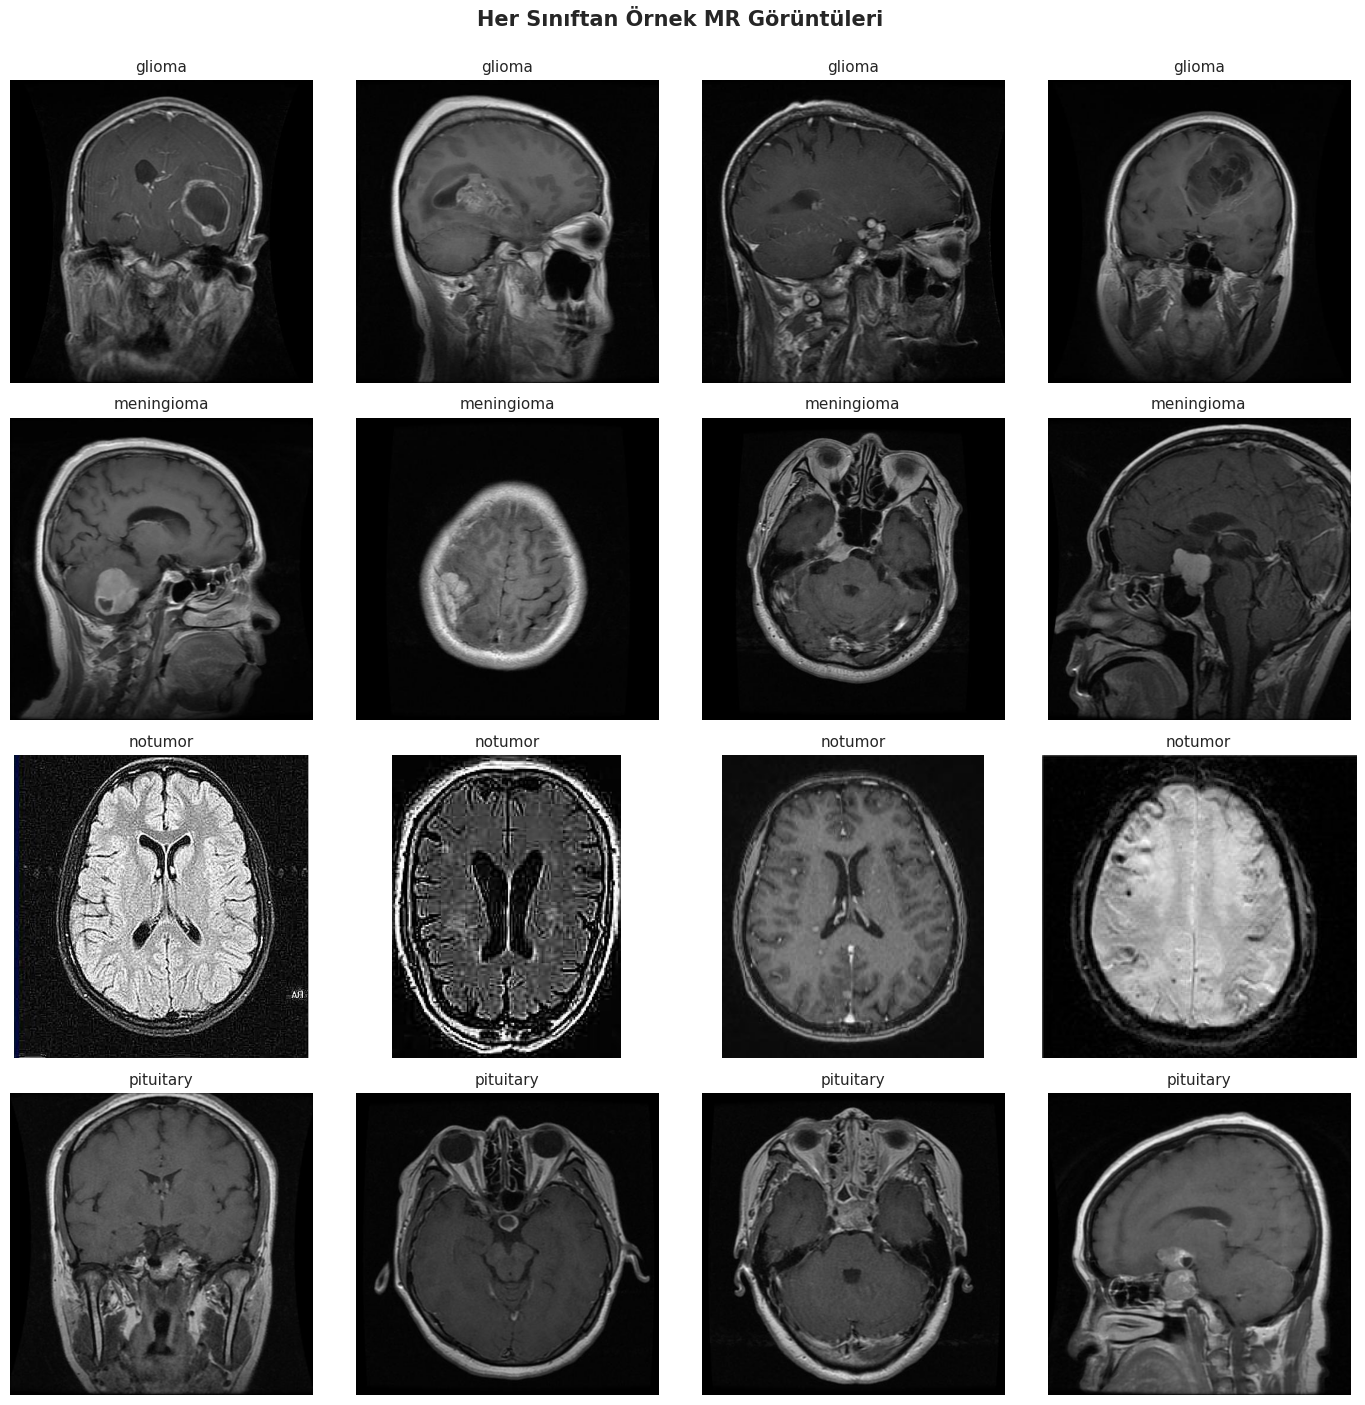

In [ ]:
# Her sınıftan örnek görüntüler
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    samples = os.listdir(cls_dir)[:4]
    for j, sample in enumerate(samples):
        img = cv2.imread(os.path.join(cls_dir, sample))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{cls}', fontsize=11)
        axes[i, j].axis('off')
plt.suptitle('Her Sınıftan Örnek MR Görüntüleri', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Veri Hazırlama ve Augmentation

Eğitim verisine **veri artırma** uyguluyoruz:
- Rotation ±15°
- Width/Height shift ±10%
- Zoom ±10%
- Horizontal flip
- Brightness ±10%

Doğrulama ve test için sadece normalizasyon yapıyoruz.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    validation_split=0.15,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training',
    shuffle=True, seed=SEED, classes=CLASS_NAMES
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False, seed=SEED, classes=CLASS_NAMES
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, classes=CLASS_NAMES
)

print(f"\nEğitim örnekleri: {train_gen.samples}")
print(f"Doğrulama örnekleri: {val_gen.samples}")
print(f"Test örnekleri: {test_gen.samples}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Eğitim örnekleri: 4760
Doğrulama örnekleri: 840
Test örnekleri: 1600


In [ ]:
# Sınıf ağırlıkları (dengesizliği telafi için)
classes = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Sınıf ağırlıkları:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {class_weight_dict[i]:.3f}")

Sınıf ağırlıkları:
  glioma: 1.000
  meningioma: 1.000
  notumor: 1.000
  pituitary: 1.000


## 5. Model 1: Custom CNN (Baseline)

Sıfırdan eğitilen 4-blok'lu konvolüsyonel sinir ağı.

In [ ]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), padding='same', name='last_conv'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='CustomCNN')
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Custom CNN eğitimi
EPOCHS = 20

cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_cnn.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

cnn_history = cnn_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=cnn_callbacks,
    class_weight=class_weight_dict, verbose=1
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.6022 - loss: 0.9730
Epoch 1: val_accuracy improved from None to 0.27738, saving model to best_cnn.h5



Epoch 1: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 107s 643ms/step - accuracy: 0.6466 - loss: 0.8659 - val_accuracy: 0.2774 - val_loss: 1.8509 - learning_rate: 0.0010
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.7068 - loss: 0.7493
Epoch 2: val_accuracy improved from 0.27738 to 0.39167, saving model to best_cnn.h5



Epoch 2: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 532ms/step - accuracy: 0.7095 - loss: 0.7277 - val_accuracy: 0.3917 - val_loss: 1.4651 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.7375 - loss: 0.6484
Epoch 3: val_accuracy improved from 0.39167 to 0.44524, saving model to best_cnn.h5



Epoch 3: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 524ms/step - accuracy: 0.7418 - loss: 0.6511 - val_accuracy: 0.4452 - val_loss: 1.2929 - learning_rate: 0.0010
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.7625 - loss: 0.6148
Epoch 4: val_accuracy improved from 0.44524 to 0.49405, saving model to best_cnn.h5



Epoch 4: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 520ms/step - accuracy: 0.7695 - loss: 0.5951 - val_accuracy: 0.4940 - val_loss: 1.8418 - learning_rate: 0.0010
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7813 - loss: 0.5667
Epoch 5: val_accuracy improved from 0.49405 to 0.71071, saving model to best_cnn.h5



Epoch 5: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 522ms/step - accuracy: 0.7870 - loss: 0.5646 - val_accuracy: 0.7107 - val_loss: 0.6738 - learning_rate: 0.0010
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8157 - loss: 0.4896
Epoch 6: val_accuracy did not improve from 0.71071
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 523ms/step - accuracy: 0.8139 - loss: 0.5016 - val_accuracy: 0.6595 - val_loss: 1.3151 - learning_rate: 0.0010
Epoch 7/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8124 - loss: 0.5180
Epoch 7: val_accuracy did not improve from 0.71071
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 519ms/step - accuracy: 0.8189 - loss: 0.4869 - val_accuracy: 0.6798 - val_loss: 1.3043 - learning_rate: 0.0010
Epoch 8/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8213 - loss: 0.4819
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: val_accuracy did not improve from 0.71071
149/149 ━━━━━━━━━━━━━━━━━━━


Epoch 10: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 528ms/step - accuracy: 0.8513 - loss: 0.4183 - val_accuracy: 0.7560 - val_loss: 0.6304 - learning_rate: 5.0000e-04
Epoch 11/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8591 - loss: 0.3842
Epoch 11: val_accuracy improved from 0.75595 to 0.80357, saving model to best_cnn.h5



Epoch 11: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 529ms/step - accuracy: 0.8603 - loss: 0.3864 - val_accuracy: 0.8036 - val_loss: 0.5238 - learning_rate: 5.0000e-04
Epoch 12/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8552 - loss: 0.3868
Epoch 12: val_accuracy improved from 0.80357 to 0.84048, saving model to best_cnn.h5



Epoch 12: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 522ms/step - accuracy: 0.8603 - loss: 0.3746 - val_accuracy: 0.8405 - val_loss: 0.4283 - learning_rate: 5.0000e-04
Epoch 13/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.8669 - loss: 0.3607
Epoch 13: val_accuracy did not improve from 0.84048
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 528ms/step - accuracy: 0.8574 - loss: 0.3825 - val_accuracy: 0.4571 - val_loss: 2.8361 - learning_rate: 5.0000e-04
Epoch 14/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8643 - loss: 0.3744
Epoch 14: val_accuracy did not improve from 0.84048
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 525ms/step - accuracy: 0.8647 - loss: 0.3662 - val_accuracy: 0.7226 - val_loss: 0.9919 - learning_rate: 5.0000e-04
Epoch 15/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8740 - loss: 0.3472
Epoch 15: val_accuracy did not improve from 0.84048
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 526ms/step - accuracy: 0.8664 - loss: 0.3701 - val_a


Epoch 20: finished saving model to best_cnn.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 523ms/step - accuracy: 0.8931 - loss: 0.3045 - val_accuracy: 0.8560 - val_loss: 0.3953 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 20.


## 6. Model 2: EfficientNetB0 (Transfer Learning)

ImageNet üzerinde önceden eğitilmiş EfficientNetB0 modeli + custom classification head. Son 30 katman fine-tuning için açıldı.

In [ ]:
def build_efficientnet(input_shape=(224, 224, 3), num_classes=4):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False
    # Son 30 katmanı fine-tuning için aç (BatchNorm hariç)
    for layer in base_model.layers[-30:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    # 🔧 KRİTİK DÜZELTME: EfficientNet [0, 255] aralığında veri bekliyor,
    # bizim verimiz [0, 1]'de — bu yüzden 255 ile çarpıyoruz
    x = layers.Lambda(lambda v: v * 255.0)(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='EfficientNetB0_TL')
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

eff_model = build_efficientnet()
eff_model.summary()

Model: "EfficientNetB0_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 1,647,844 (6.29 MB)

 Non-trainable params: 2,566,211 (9.79 MB)

In [ ]:
# EfficientNetB0 eğitimi
eff_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_efficientnet.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

eff_history = eff_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=eff_callbacks,
    class_weight=class_weight_dict, verbose=1
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.5761 - loss: 0.9957
Epoch 1: val_accuracy improved from None to 0.86548, saving model to best_efficientnet.h5



Epoch 1: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 126s 680ms/step - accuracy: 0.7042 - loss: 0.7326 - val_accuracy: 0.8655 - val_loss: 0.3948 - learning_rate: 1.0000e-04
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.8414 - loss: 0.4151
Epoch 2: val_accuracy improved from 0.86548 to 0.88333, saving model to best_efficientnet.h5



Epoch 2: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 515ms/step - accuracy: 0.8492 - loss: 0.4000 - val_accuracy: 0.8833 - val_loss: 0.3249 - learning_rate: 1.0000e-04
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8785 - loss: 0.3307
Epoch 3: val_accuracy improved from 0.88333 to 0.89881, saving model to best_efficientnet.h5



Epoch 3: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 517ms/step - accuracy: 0.8849 - loss: 0.3114 - val_accuracy: 0.8988 - val_loss: 0.2708 - learning_rate: 1.0000e-04
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9137 - loss: 0.2483
Epoch 4: val_accuracy improved from 0.89881 to 0.90357, saving model to best_efficientnet.h5



Epoch 4: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.9107 - loss: 0.2534 - val_accuracy: 0.9036 - val_loss: 0.2445 - learning_rate: 1.0000e-04
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9231 - loss: 0.2158
Epoch 5: val_accuracy did not improve from 0.90357
149/149 ━━━━━━━━━━━━━━━━━━━━ 76s 512ms/step - accuracy: 0.9202 - loss: 0.2148 - val_accuracy: 0.8940 - val_loss: 0.2491 - learning_rate: 1.0000e-04
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9286 - loss: 0.1825
Epoch 6: val_accuracy improved from 0.90357 to 0.91310, saving model to best_efficientnet.h5


...


Epoch 12: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 519ms/step - accuracy: 0.9613 - loss: 0.1046 - val_accuracy: 0.9536 - val_loss: 0.1305 - learning_rate: 1.0000e-04
Epoch 13/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9677 - loss: 0.0865
Epoch 13: val_accuracy did not improve from 0.95357
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 517ms/step - accuracy: 0.9676 - loss: 0.0883 - val_accuracy: 0.9476 - val_loss: 0.1321 - learning_rate: 1.0000e-04
Epoch 14/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9720 - loss: 0.0855
Epoch 14: val_accuracy did not improve from 0.95357
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 515ms/step - accuracy: 0.9706 - loss: 0.0865 - val_accuracy: 0.9524 - val_loss: 0.1320 - learning_rate: 1.0000e-04
Epoch 15/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9741 - loss: 0.0708
Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 15: val_accuracy did not improve from 0.9535


Epoch 16: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 518ms/step - accuracy: 0.9727 - loss: 0.0704 - val_accuracy: 0.9548 - val_loss: 0.1401 - learning_rate: 5.0000e-05
Epoch 17/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9790 - loss: 0.0636
Epoch 17: val_accuracy improved from 0.95476 to 0.96310, saving model to best_efficientnet.h5



Epoch 17: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 78s 522ms/step - accuracy: 0.9805 - loss: 0.0554 - val_accuracy: 0.9631 - val_loss: 0.1058 - learning_rate: 5.0000e-05
Epoch 18/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9813 - loss: 0.0558
Epoch 18: val_accuracy improved from 0.96310 to 0.96429, saving model to best_efficientnet.h5



Epoch 18: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 518ms/step - accuracy: 0.9819 - loss: 0.0543 - val_accuracy: 0.9643 - val_loss: 0.0990 - learning_rate: 5.0000e-05
Epoch 19/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9814 - loss: 0.0567
Epoch 19: val_accuracy did not improve from 0.96429
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 514ms/step - accuracy: 0.9794 - loss: 0.0606 - val_accuracy: 0.9643 - val_loss: 0.1143 - learning_rate: 5.0000e-05
Epoch 20/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9816 - loss: 0.0559
Epoch 20: val_accuracy improved from 0.96429 to 0.96905, saving model to best_efficientnet.h5



Epoch 20: finished saving model to best_efficientnet.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 518ms/step - accuracy: 0.9821 - loss: 0.0521 - val_accuracy: 0.9690 - val_loss: 0.1062 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 18.


## 7. Eğitim Eğrileri

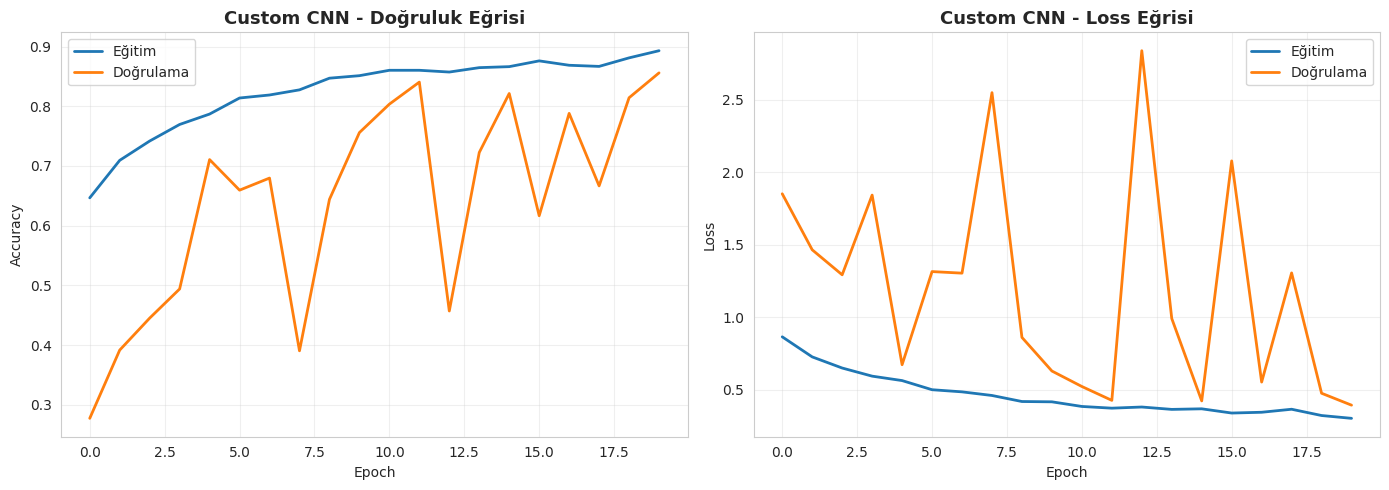

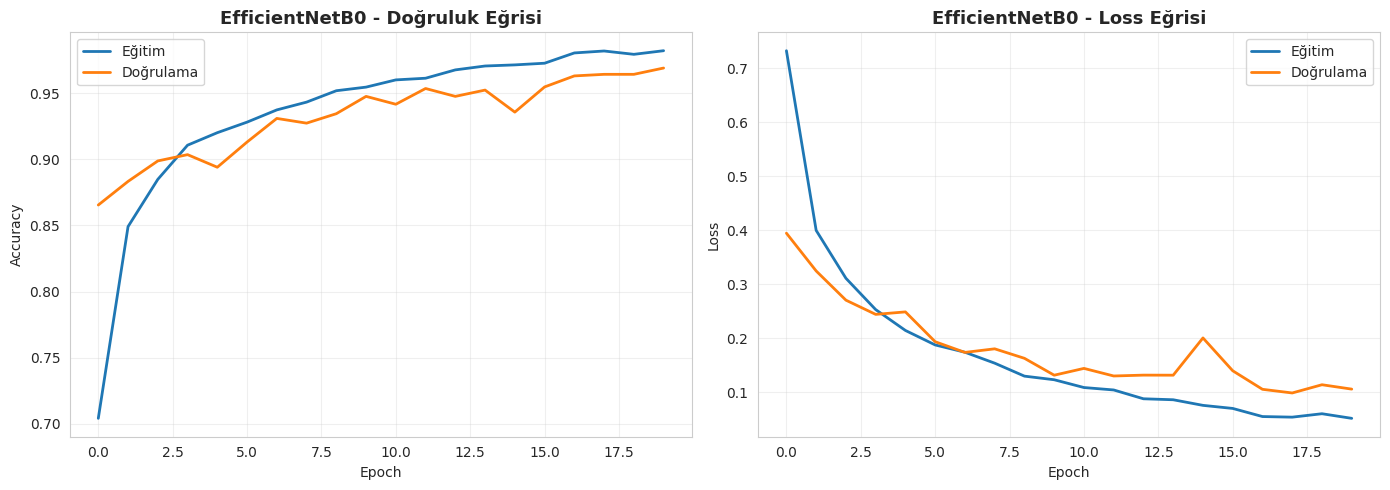

In [ ]:
def plot_training_curves(history, model_name, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Eğitim', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Doğrulama', linewidth=2)
    axes[0].set_title(f'{model_name} - Doğruluk Eğrisi', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Eğitim', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Doğrulama', linewidth=2)
    axes[1].set_title(f'{model_name} - Loss Eğrisi', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(cnn_history, 'Custom CNN', 'training_curves_cnn.png')
plot_training_curves(eff_history, 'EfficientNetB0', 'training_curves_efficientnet.png')

## 8. Model Değerlendirmesi

In [ ]:
def evaluate_model(model, test_gen, class_names, model_name):
    test_gen.reset()
    y_pred_proba = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    mp, mr, mf, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    wp, wr, wf, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision: {mp:.4f} | Macro Recall: {mr:.4f} | Macro F1: {mf:.4f}")
    print(f"Weighted F1: {wf:.4f}")
    print("\nPer-class metrics:")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: P={p[i]:.3f} R={r[i]:.3f} F1={f[i]:.3f} (n={s[i]})")

    return {
        'accuracy': acc, 'macro_precision': mp, 'macro_recall': mr,
        'macro_f1': mf, 'weighted_f1': wf,
        'precision_per_class': p, 'recall_per_class': r,
        'f1_per_class': f, 'support_per_class': s,
        'cm': confusion_matrix(y_true, y_pred),
        'y_true': y_true, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
    }

cnn_results = evaluate_model(cnn_model, test_gen, CLASS_NAMES, 'Custom CNN')
eff_results = evaluate_model(eff_model, test_gen, CLASS_NAMES, 'EfficientNetB0')

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step

=== Custom CNN ===
Accuracy: 0.8175
Macro Precision: 0.8383 | Macro Recall: 0.8175 | Macro F1: 0.8082
Weighted F1: 0.8082

Per-class metrics:
  glioma: P=0.995 R=0.552 F1=0.711 (n=400)
  meningioma: P=0.717 R=0.748 F1=0.732 (n=400)
  notumor: P=0.838 R=0.980 F1=0.903 (n=400)
  pituitary: P=0.803 R=0.990 F1=0.887 (n=400)
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step

=== EfficientNetB0 ===
Accuracy: 0.9319
Macro Precision: 0.9357 | Macro Recall: 0.9319 | Macro F1: 0.9304
Weighted F1: 0.9304

Per-class metrics:
  glioma: P=0.975 R=0.787 F1=0.871 (n=400)
  meningioma: P=0.854 R=0.950 F1=0.899 (n=400)
  notumor: P=0.955 R=0.998 F1=0.976 (n=400)
  pituitary: P=0.959 R=0.993 F1=0.975 (n=400)


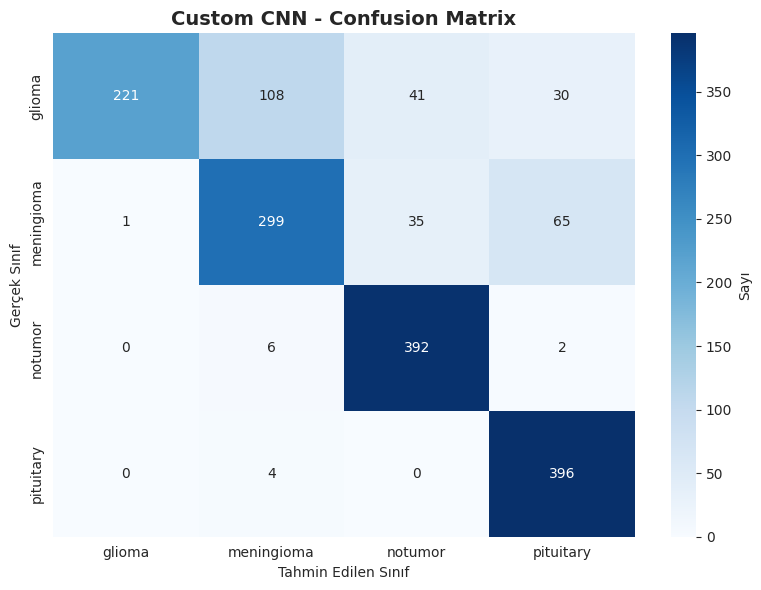

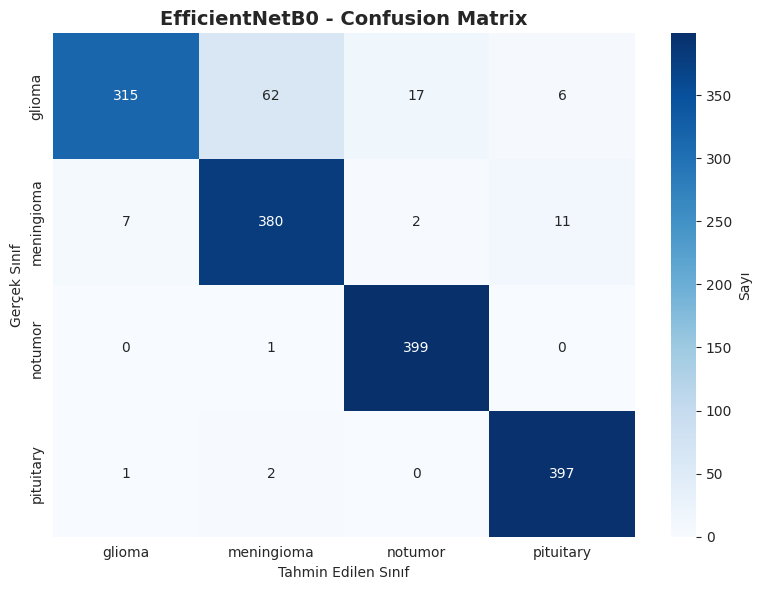

In [ ]:
# Confusion matrix'leri çiz
def plot_cm(cm, class_names, title, save_path):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Sayı'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Gerçek Sınıf'); plt.xlabel('Tahmin Edilen Sınıf')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_cm(cnn_results['cm'], CLASS_NAMES, 'Custom CNN - Confusion Matrix', 'cm_cnn.png')
plot_cm(eff_results['cm'], CLASS_NAMES, 'EfficientNetB0 - Confusion Matrix', 'cm_efficientnet.png')

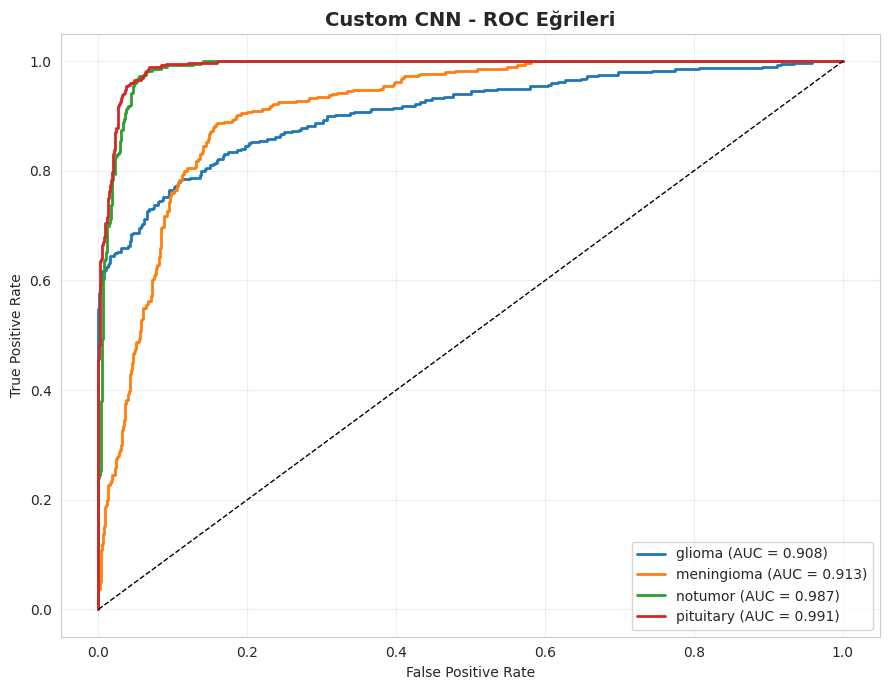

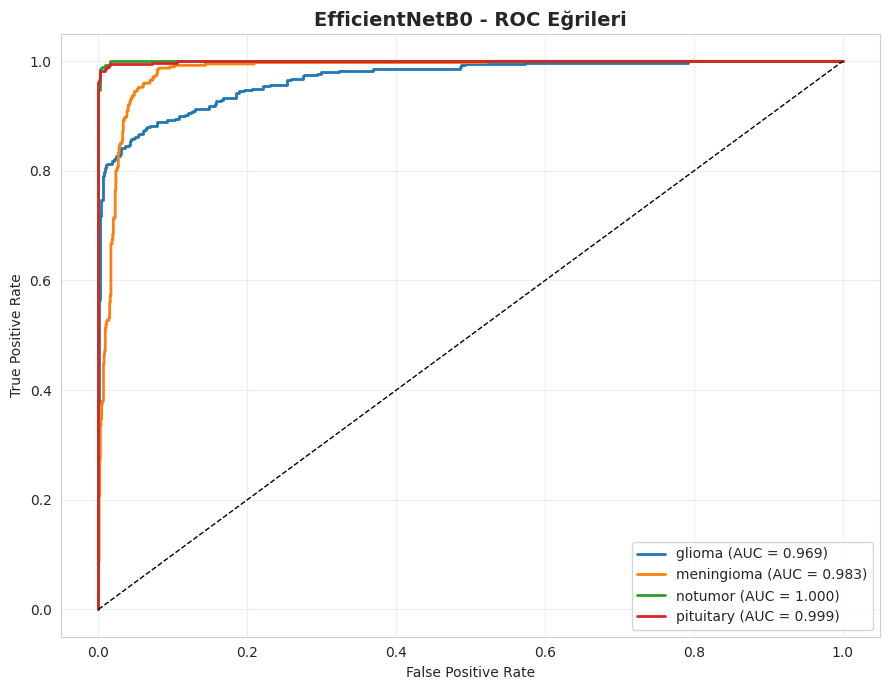


Ortalama AUC - Custom CNN: 0.9499
Ortalama AUC - EfficientNetB0: 0.9876


In [ ]:
# ROC eğrileri (One-vs-Rest)
def plot_roc(y_true, y_pred_proba, class_names, title, save_path):
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(9, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    aucs = []
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return aucs

cnn_aucs = plot_roc(cnn_results['y_true'], cnn_results['y_pred_proba'],
                     CLASS_NAMES, 'Custom CNN - ROC Eğrileri', 'roc_cnn.png')
eff_aucs = plot_roc(eff_results['y_true'], eff_results['y_pred_proba'],
                     CLASS_NAMES, 'EfficientNetB0 - ROC Eğrileri', 'roc_efficientnet.png')
print(f"\nOrtalama AUC - Custom CNN: {np.mean(cnn_aucs):.4f}")
print(f"Ortalama AUC - EfficientNetB0: {np.mean(eff_aucs):.4f}")

## 9. Model Karşılaştırma Tablosu

In [ ]:
# Karşılaştırma tablosu
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'EfficientNetB0'],
    'Accuracy': [f"{cnn_results['accuracy']:.4f}", f"{eff_results['accuracy']:.4f}"],
    'Macro Precision': [f"{cnn_results['macro_precision']:.4f}", f"{eff_results['macro_precision']:.4f}"],
    'Macro Recall': [f"{cnn_results['macro_recall']:.4f}", f"{eff_results['macro_recall']:.4f}"],
    'Macro F1': [f"{cnn_results['macro_f1']:.4f}", f"{eff_results['macro_f1']:.4f}"],
    'Weighted F1': [f"{cnn_results['weighted_f1']:.4f}", f"{eff_results['weighted_f1']:.4f}"],
    'Mean AUC': [f"{np.mean(cnn_aucs):.4f}", f"{np.mean(eff_aucs):.4f}"],
    'Parameters': [f"{cnn_model.count_params():,}", f"{eff_model.count_params():,}"]
})
comparison.to_csv('model_comparison.csv', index=False)
print(comparison.to_string(index=False))

         Model Accuracy Macro Precision Macro Recall Macro F1 Weighted F1 Mean AUC Parameters
    Custom CNN   0.8175          0.8383       0.8175   0.8082      0.8082   0.9499    423,748
EfficientNetB0   0.9319          0.9357       0.9319   0.9304      0.9304   0.9876  4,214,055


In [ ]:
# Per-class detaylı metrik tablosu
def per_class_df(results, model_name, class_names):
    return pd.DataFrame({
        'Model': [model_name] * len(class_names),
        'Sınıf': class_names,
        'Precision': [f"{p:.4f}" for p in results['precision_per_class']],
        'Recall': [f"{r:.4f}" for r in results['recall_per_class']],
        'F1-Score': [f"{f:.4f}" for f in results['f1_per_class']],
        'Support': results['support_per_class']
    })

per_class_cnn = per_class_df(cnn_results, 'Custom CNN', CLASS_NAMES)
per_class_eff = per_class_df(eff_results, 'EfficientNetB0', CLASS_NAMES)
per_class_combined = pd.concat([per_class_cnn, per_class_eff], ignore_index=True)
per_class_combined.to_csv('per_class_metrics.csv', index=False)
print(per_class_combined.to_string(index=False))

         Model      Sınıf Precision Recall F1-Score  Support
    Custom CNN     glioma    0.9955 0.5525   0.7106      400
    Custom CNN meningioma    0.7170 0.7475   0.7319      400
    Custom CNN    notumor    0.8376 0.9800   0.9032      400
    Custom CNN  pituitary    0.8032 0.9900   0.8869      400
EfficientNetB0     glioma    0.9752 0.7875   0.8714      400
EfficientNetB0 meningioma    0.8539 0.9500   0.8994      400
EfficientNetB0    notumor    0.9545 0.9975   0.9756      400
EfficientNetB0  pituitary    0.9589 0.9925   0.9754      400


## 10. Grad-CAM Açıklanabilirlik Analizi

En başarılı model üzerinde Grad-CAM uygulayarak modelin karar verirken görüntünün hangi bölgelerine odaklandığını görselleştiriyoruz.

In [ ]:
# En iyi modeli seç
if eff_results['accuracy'] >= cnn_results['accuracy']:
    best_model = eff_model
    best_model_name = 'EfficientNetB0'
    # EfficientNet için son conv katmanı
    last_conv_layer_name = 'top_conv'
else:
    best_model = cnn_model
    best_model_name = 'Custom CNN'
    last_conv_layer_name = 'last_conv'

print(f"✓ En iyi model: {best_model_name}")
print(f"✓ Son conv katmanı: {last_conv_layer_name}")

✓ En iyi model: EfficientNetB0
✓ Son conv katmanı: top_conv


In [ ]:
# Grad-CAM fonksiyonları (Lambda katmanı dahil iç içe modelleri destekler)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # EfficientNet sub-model'ini bul (varsa)
    base_model = None
    base_idx = -1
    for i, layer in enumerate(model.layers):
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            base_idx = i
            break

    if base_model is None:
        # Düz model (Custom CNN gibi)
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[model.get_layer(last_conv_layer_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_out, preds = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]
        grads = tape.gradient(class_channel, conv_out)
    else:
        # İç içe model (EfficientNet + Lambda)
        sub_grad_model = tf.keras.models.Model(
            inputs=base_model.input,
            outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
        )
        pre_layers = [l for i, l in enumerate(model.layers)
                      if i < base_idx and not isinstance(l, tf.keras.layers.InputLayer)]
        post_layers = [l for i, l in enumerate(model.layers)
                       if i > base_idx and not isinstance(l, tf.keras.layers.InputLayer)]

        with tf.GradientTape() as tape:
            x = img_array
            for layer in pre_layers:
                x = layer(x)
            conv_out, base_out = sub_grad_model(x)
            x = base_out
            for layer in post_layers:
                x = layer(x)
            preds = x
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]

        grads = tape.gradient(class_channel, conv_out)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out_val = conv_out[0]
    heatmap = conv_out_val @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()


def overlay_heatmap(img, heatmap, alpha=0.4):
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlayed = heatmap_color * alpha + img * (1 - alpha)
    return np.clip(overlayed, 0, 255).astype(np.uint8)

print("✓ Grad-CAM fonksiyonları hazır (iç içe model destekli)")

✓ Grad-CAM fonksiyonları hazır (iç içe model destekli)


In [ ]:
# Test setinden her sınıftan 2 örnek seçip Grad-CAM uygula
test_gen.reset()
all_images, all_labels = [], []
for i in range(min(20, len(test_gen))):
    batch_x, batch_y = next(test_gen)
    all_images.append(batch_x)
    all_labels.append(batch_y)
all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)
all_labels_idx = np.argmax(all_labels, axis=1)

# Her sınıftan 2 örnek
selected_indices = []
for cls_idx in range(4):
    cls_samples = np.where(all_labels_idx == cls_idx)[0][:2]
    selected_indices.extend(cls_samples)

print(f"Seçilen örnek sayısı: {len(selected_indices)}")

Seçilen örnek sayısı: 4


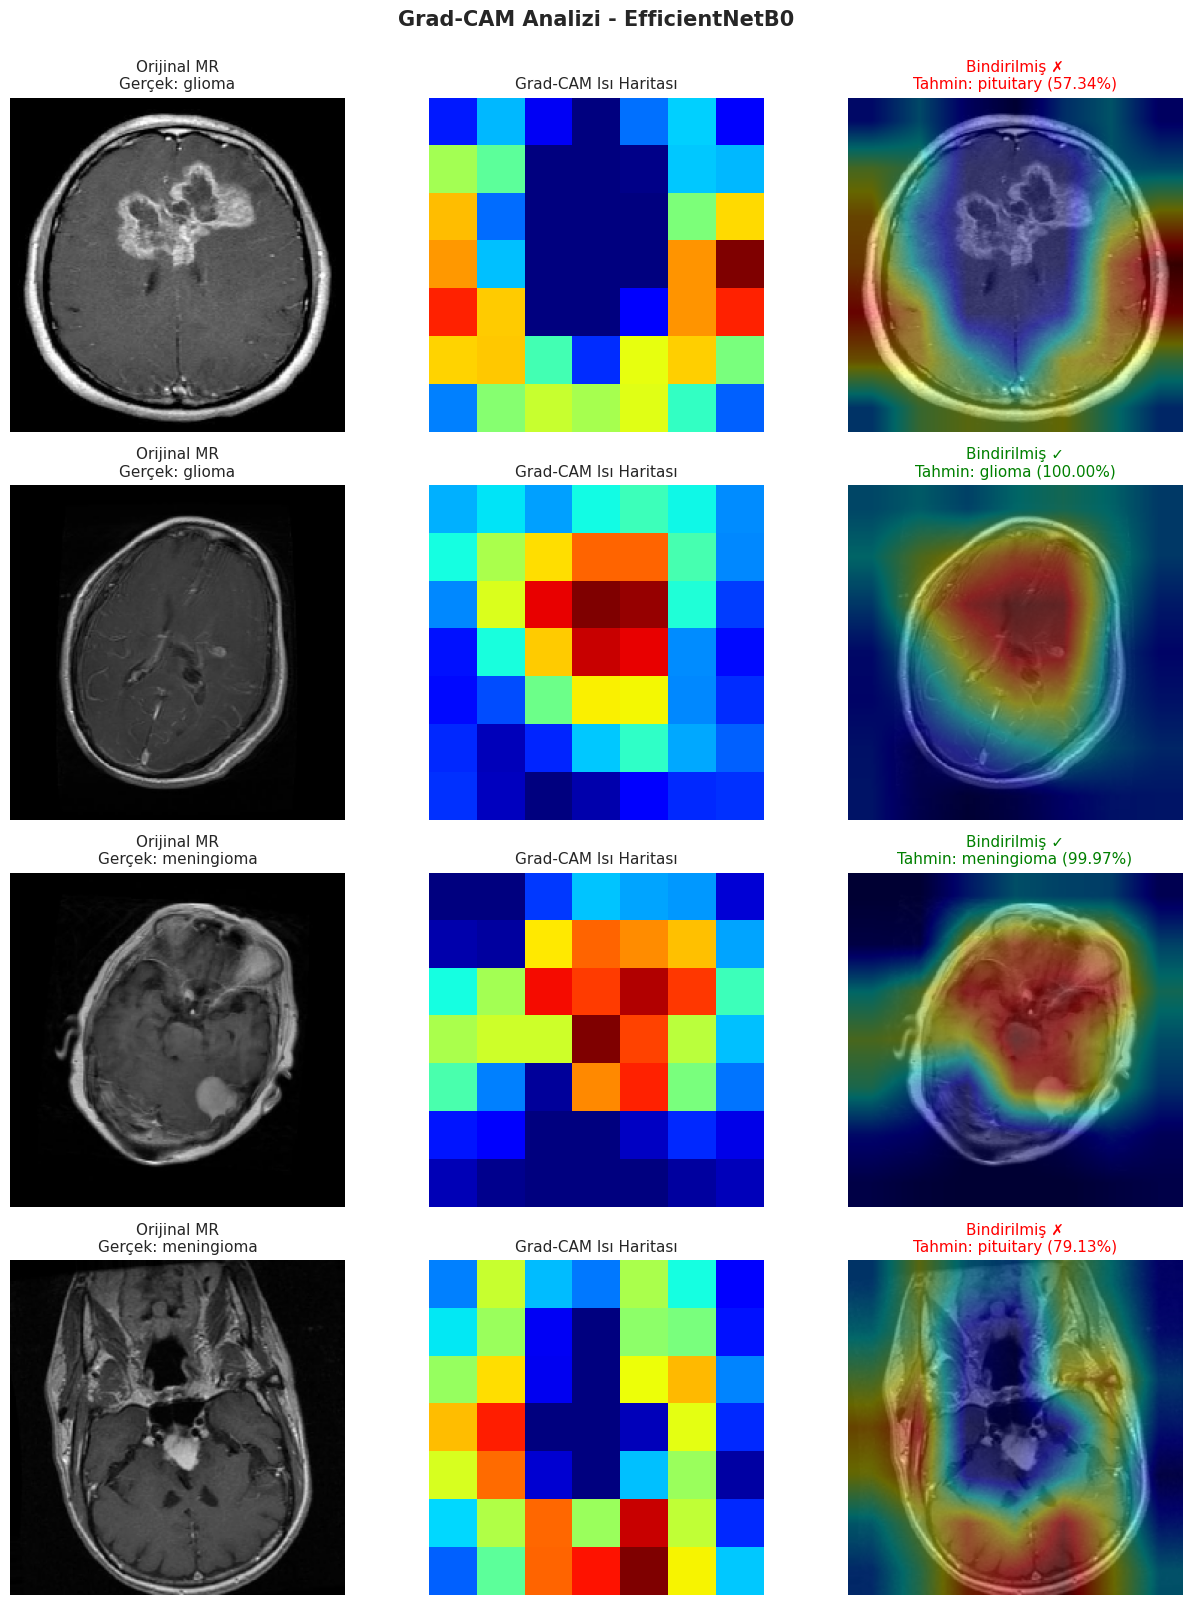

In [ ]:
# Grad-CAM görsellerini grid olarak çiz
n_samples = len(selected_indices)
fig, axes = plt.subplots(n_samples, 3, figsize=(13, 4 * n_samples))

for row, idx in enumerate(selected_indices):
    img = all_images[idx]
    true_idx = all_labels_idx[idx]
    img_batch = np.expand_dims(img, axis=0)

    preds = best_model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    heatmap = make_gradcam_heatmap(img_batch, best_model, last_conv_layer_name)
    overlay = overlay_heatmap(img, heatmap, alpha=0.4)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Orijinal MR\nGerçek: {CLASS_NAMES[true_idx]}', fontsize=11)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title('Grad-CAM Isı Haritası', fontsize=11)
    axes[row, 1].axis('off')

    correct = '✓' if pred_idx == true_idx else '✗'
    color = 'green' if pred_idx == true_idx else 'red'
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f'Bindirilmiş {correct}\nTahmin: {CLASS_NAMES[pred_idx]} ({confidence:.2%})',
        fontsize=11, color=color
    )
    axes[row, 2].axis('off')

plt.suptitle(f'Grad-CAM Analizi - {best_model_name}', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Örnek Tahminler (Gerçek vs Tahmin + Confidence)

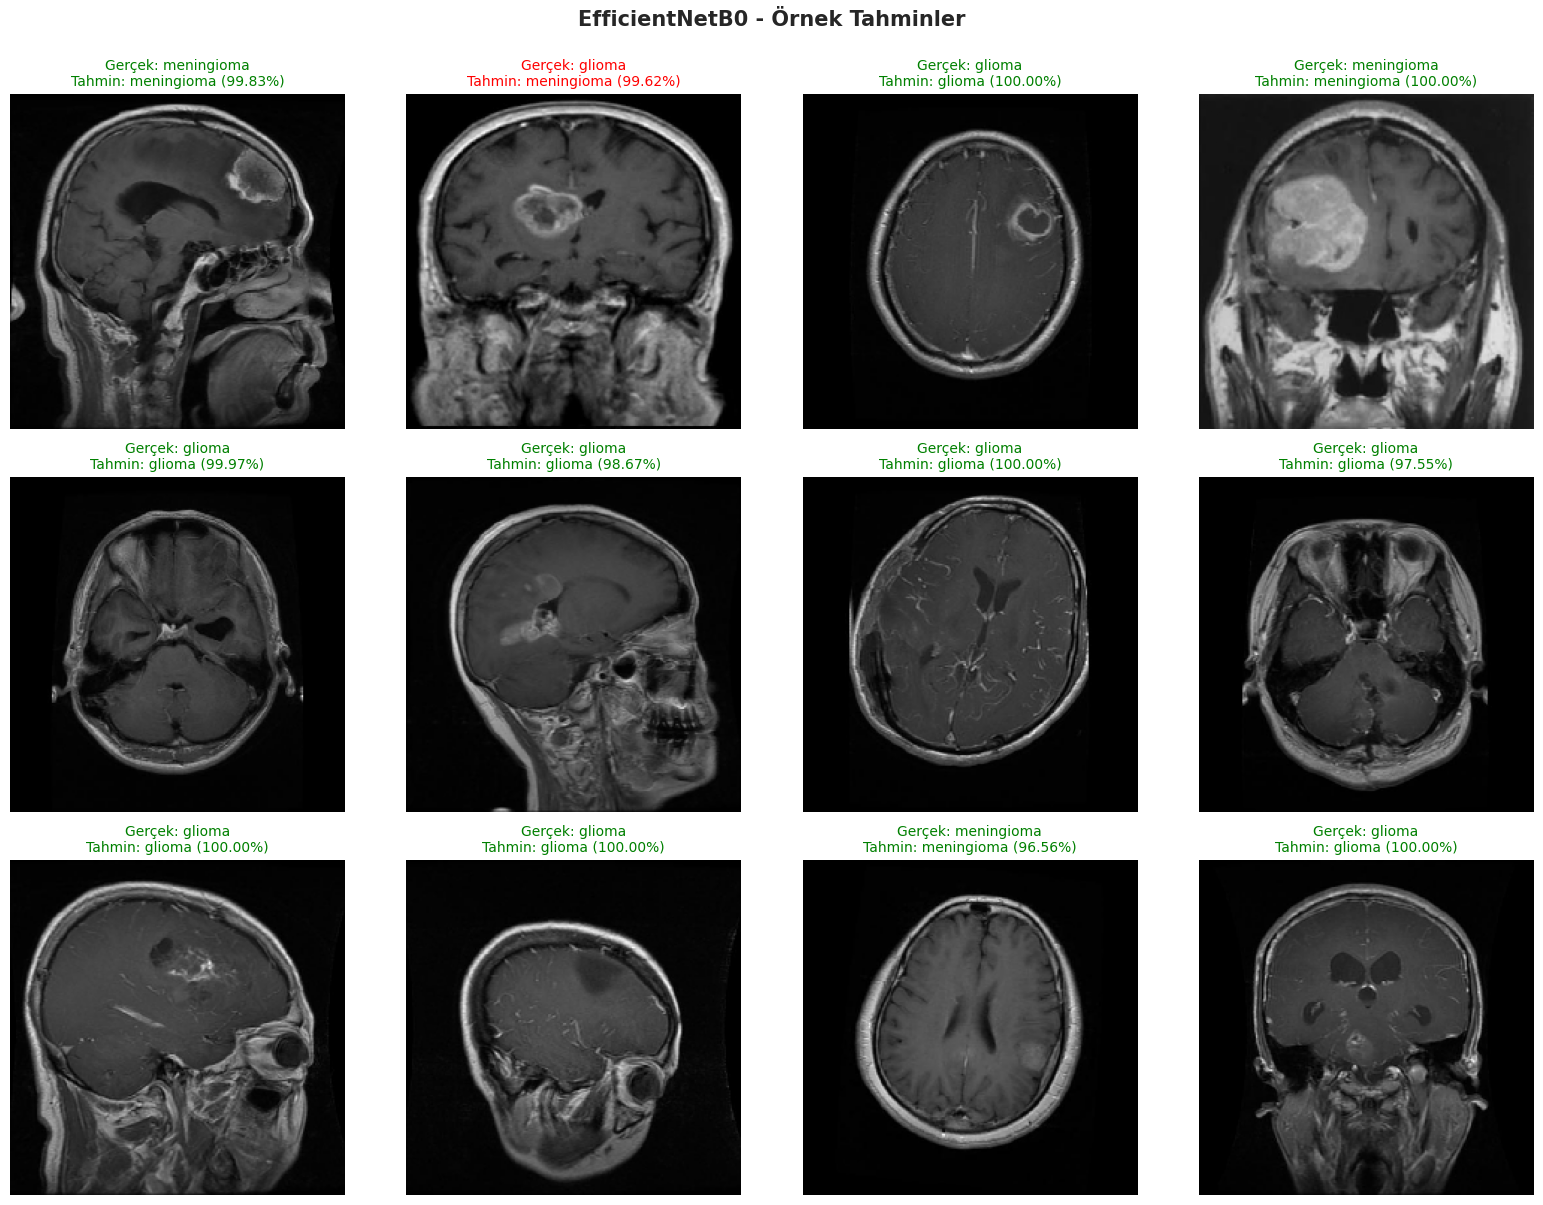

In [ ]:
# 12 rastgele örnek üzerinde tahmin
np.random.seed(SEED)
random_idx = np.random.choice(len(all_images), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, idx in enumerate(random_idx):
    img = all_images[idx]
    true_idx = all_labels_idx[idx]
    preds = best_model.predict(np.expand_dims(img, 0), verbose=0)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    correct = pred_idx == true_idx
    color = 'green' if correct else 'red'
    axes[i].imshow(img)
    axes[i].set_title(
        f'Gerçek: {CLASS_NAMES[true_idx]}\nTahmin: {CLASS_NAMES[pred_idx]} ({confidence:.2%})',
        fontsize=10, color=color
    )
    axes[i].axis('off')

plt.suptitle(f'{best_model_name} - Örnek Tahminler', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Sonuçları Drive'a Kaydetme

In [ ]:
# Tüm sonuç dosyalarını zip'le
import zipfile

result_files = [
    'class_distribution.png', 'sample_images.png',
    'training_curves_cnn.png', 'training_curves_efficientnet.png',
    'cm_cnn.png', 'cm_efficientnet.png',
    'roc_cnn.png', 'roc_efficientnet.png',
    'model_comparison.csv', 'per_class_metrics.csv',
    'gradcam_results.png', 'sample_predictions.png',
    'best_cnn.h5', 'best_efficientnet.h5'
]

with zipfile.ZipFile('project_results.zip', 'w') as zipf:
    for f in result_files:
        if os.path.exists(f):
            zipf.write(f)
            print(f"  ✓ {f}")

print("\n✓ Tüm sonuçlar 'project_results.zip' dosyasına paketlendi.")
print("Sol panelden indirip GitHub repo'nuzun results/ klasörüne kopyalayın.")

  ✓ class_distribution.png
  ✓ sample_images.png
  ✓ training_curves_cnn.png
  ✓ training_curves_efficientnet.png
  ✓ cm_cnn.png
  ✓ cm_efficientnet.png
  ✓ roc_cnn.png
  ✓ roc_efficientnet.png
  ✓ model_comparison.csv
  ✓ per_class_metrics.csv
  ✓ gradcam_results.png
  ✓ sample_predictions.png
  ✓ best_cnn.h5
  ✓ best_efficientnet.h5

✓ Tüm sonuçlar 'project_results.zip' dosyasına paketlendi.
Sol panelden indirip GitHub repo'nuzun results/ klasörüne kopyalayın.


In [ ]:
# Eğitim geçmişlerini de kaydet (rapor için)
import json

history_data = {
    'cnn': {
        'accuracy': cnn_history.history['accuracy'],
        'val_accuracy': cnn_history.history['val_accuracy'],
        'loss': cnn_history.history['loss'],
        'val_loss': cnn_history.history['val_loss']
    },
    'efficientnet': {
        'accuracy': eff_history.history['accuracy'],
        'val_accuracy': eff_history.history['val_accuracy'],
        'loss': eff_history.history['loss'],
        'val_loss': eff_history.history['val_loss']
    },
    'final_results': {
        'cnn_accuracy': float(cnn_results['accuracy']),
        'cnn_macro_f1': float(cnn_results['macro_f1']),
        'eff_accuracy': float(eff_results['accuracy']),
        'eff_macro_f1': float(eff_results['macro_f1']),
        'best_model': best_model_name
    }
}

with open('training_history.json', 'w') as f:
    json.dump(history_data, f, indent=2)
print("✓ training_history.json kaydedildi")
print(f"\n🎯 En iyi model: {best_model_name}")
print(f"🎯 En iyi doğruluk: {max(cnn_results['accuracy'], eff_results['accuracy']):.4f}")

✓ training_history.json kaydedildi

🎯 En iyi model: EfficientNetB0
🎯 En iyi doğruluk: 0.9319


## ✅ Proje Tamamlandı!

Eğitim, değerlendirme ve Grad-CAM analizi başarıyla tamamlandı. `project_results.zip` dosyasını indirip GitHub repo'nuzun ilgili klasörlerine kopyalayın.

Sonraki adımlar:
1. ✅ Sonuçları GitHub'a yükle
2. ✅ README'yi güncelle (gerçek sonuç değerleri ile)
3. ✅ Raporu yaz
4. ✅ Broşürü hazırla
5. ✅ Demo video çek


In [4]:
# === KURTARMA: Modelleri diskten yükle ve AUC hesapla ===
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 1) Veri seti kontrolü
if not os.path.exists('data/Testing'):
    print("❌ Veri seti yok — yukarıdaki Kaggle indirme hücresini tekrar çalıştır")
else:
    print(f"✓ data/Testing klasörü bulundu")

    # 2) Test generator
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_gen = test_datagen.flow_from_directory(
        'data/Testing', target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False, classes=CLASS_NAMES
    )

    # 3) Modelleri diskten yükle
    print("\nModeller yükleniyor...")
    cnn_model = load_model('best_cnn.h5', compile=False)
    print("✓ Custom CNN diskten yüklendi")

    eff_model = load_model('best_efficientnet.h5', compile=False, safe_mode=False)
    print("✓ EfficientNetB0 diskten yüklendi")

    # 4) Predictions
    test_gen.reset()
    print("\nCustom CNN tahminleri...")
    cnn_pred_proba = cnn_model.predict(test_gen, verbose=1)

    test_gen.reset()
    print("EfficientNet tahminleri...")
    eff_pred_proba = eff_model.predict(test_gen, verbose=1)

    # 5) AUC hesapla
    y_true = test_gen.classes
    y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
    cnn_auc = roc_auc_score(y_true_bin, cnn_pred_proba, average='macro', multi_class='ovr')
    eff_auc = roc_auc_score(y_true_bin, eff_pred_proba, average='macro', multi_class='ovr')

    print(f"\n🎯 SONUÇLAR:")
    print(f"  Custom CNN Mean AUC:     {cnn_auc:.4f}")
    print(f"  EfficientNetB0 Mean AUC: {eff_auc:.4f}")

❌ Veri seti yok — yukarıdaki Kaggle indirme hücresini tekrar çalıştır
